### <u> **Title<u> - <span style="font-size: 24px; font-weight: bold; color: red; ">Predicting Movie Success using Machine Learning<span>**

 ### <u>**Project Objective<u> : <span style="font-size: 24px; font-weight: bold; color: red;">Develop a comprehensive data analysis pipeline and a robust machine learning model to accurately predict movie success categories (Hit, Average, Flop, Blockbuster) based on various movie attributes. By utilizing this model, the studio aims to improve movie production decisions, marketing strategies, and overall film industry insights.<span>**

### **Developed By : <span style="font-size: 24px; text-decoration: underline;"> JEET ROY**

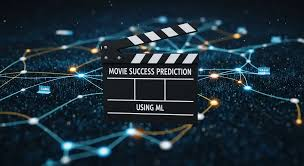

In [2]:
from IPython.display import Image, display
display(Image(filename=r"C:\Users\Jeet Roy\Downloads\movie_predict.png", width=900))

### **<u>Business Problem<u>**

**The film industry invests millions of dollars into movie production and marketing.**
**However, predicting whether a movie will become successful remains highly uncertain.**

**This project aims to build a Machine Learning system capable of predicting movie success categories based on IMDb ratings and movie attributes.**

**The insights generated from this project can help:**
- **Production Houses**
- **Streaming Platforms**
- **Investors**
- **Marketing Teams**
**make data-driven decisions**.

### **<u>Project Summary<u>**
- **Perform detailed Exploratory Data Analysis (EDA)**
- **Identify factors affecting movie success**
- **Handle missing values and data inconsistencies**
- **Engineer meaningful features**
- **Build classification models**
- **Compare multiple ML algorithms**
- **<u>Predict movie success category<u>:**
    - **Flop**
    - **Average**
    - **Hit**
- **Generate actionable business insights**
- **Create interactive dashboards in Power BI**

### **<u>Tools Used<u>**:
- **Python**
- **Pandas**
- **Numpy**
- **Scikit-Learn**
- **Seaborn**
- **Matplotlib**
- **Power BI**

**Import Libraries**

In [3]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


**Load Dataset**

In [4]:
df=pd.read_csv(r"C:\Users\Jeet Roy\Downloads\movie_metadata(in).csv")
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


**Dataset Shape**

In [5]:
df.shape

(5043, 28)

**Data Types**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

**Statistical Summary**

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_critic_for_reviews,4993.0,1.401943e+02,1.216017e+02,1.00,50.00,110.00,195.00,8.130000e+02
duration,5028.0,1.072011e+02,2.519744e+01,7.00,93.00,103.00,118.00,5.110000e+02
director_facebook_likes,4939.0,6.865092e+02,2.813329e+03,0.00,7.00,49.00,194.50,2.300000e+04
actor_3_facebook_likes,5020.0,6.450098e+02,1.665042e+03,0.00,133.00,371.50,636.00,2.300000e+04
actor_1_facebook_likes,5036.0,6.560047e+03,1.502076e+04,0.00,614.00,988.00,11000.00,6.400000e+05
gross,4159.0,4.846841e+07,6.845299e+07,162.00,5340987.50,25517500.00,62309437.50,7.605058e+08
num_voted_users,5043.0,8.366816e+04,1.384853e+05,5.00,8593.50,34359.00,96309.00,1.689764e+06
cast_total_facebook_likes,5043.0,9.699064e+03,1.816380e+04,0.00,1411.00,3090.00,13756.50,6.567300e+05
facenumber_in_poster,5030.0,1.371173e+00,2.013576e+00,0.00,0.00,1.00,2.00,4.300000e+01
num_user_for_reviews,5022.0,2.727708e+02,3.779829e+02,1.00,65.00,156.00,326.00,5.060000e+03


**Check Null Values**

In [8]:
df.isnull().sum()

color                         19
director_name                104
num_critic_for_reviews        50
duration                      15
director_facebook_likes      104
actor_3_facebook_likes        23
actor_2_name                  13
actor_1_facebook_likes         7
gross                        884
genres                         0
actor_1_name                   7
movie_title                    0
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                  23
facenumber_in_poster          13
plot_keywords                153
movie_imdb_link                0
num_user_for_reviews          21
language                      14
country                        5
content_rating               303
budget                       492
title_year                   108
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 329
movie_facebook_likes           0
dtype: int64

**Vizualize Missing Values**

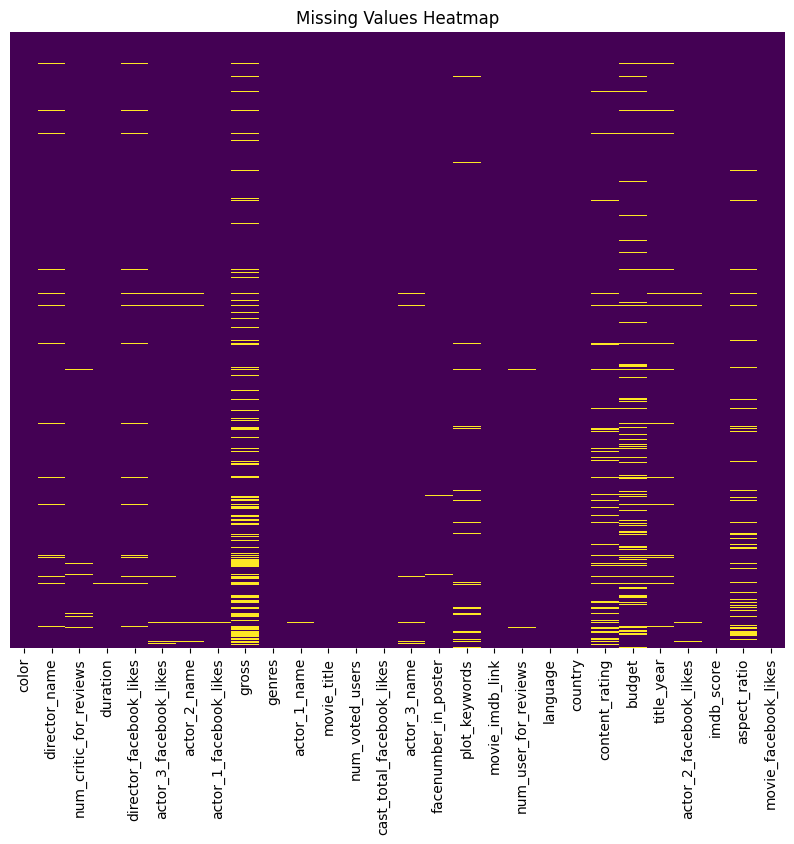

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.isnull().astype(int),
    yticklabels=False,
    cbar=False,
    cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

**Remove Duplicates**

In [10]:
print(df.duplicated().sum())

45


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
print(df.duplicated().sum())

0


**Handle Null Values**

In [13]:
#numerical column
num_col=df.select_dtypes(include=np.number).columns
for col in num_col:
    df[col].fillna(df[col].median(),inplace=True)
                   
#categorical column
cat_col=df.select_dtypes(include="object").columns
for col in cat_col:
    df[col].fillna(df[col].mode()[0],inplace=True) #[0] is for taking the first word
                   

**Verify Null Removes**

In [14]:
df.isnull().sum()

color                        0
director_name                0
num_critic_for_reviews       0
duration                     0
director_facebook_likes      0
actor_3_facebook_likes       0
actor_2_name                 0
actor_1_facebook_likes       0
gross                        0
genres                       0
actor_1_name                 0
movie_title                  0
num_voted_users              0
cast_total_facebook_likes    0
actor_3_name                 0
facenumber_in_poster         0
plot_keywords                0
movie_imdb_link              0
num_user_for_reviews         0
language                     0
country                      0
content_rating               0
budget                       0
title_year                   0
actor_2_facebook_likes       0
imdb_score                   0
aspect_ratio                 0
movie_facebook_likes         0
dtype: int64

**Feature Engineering**

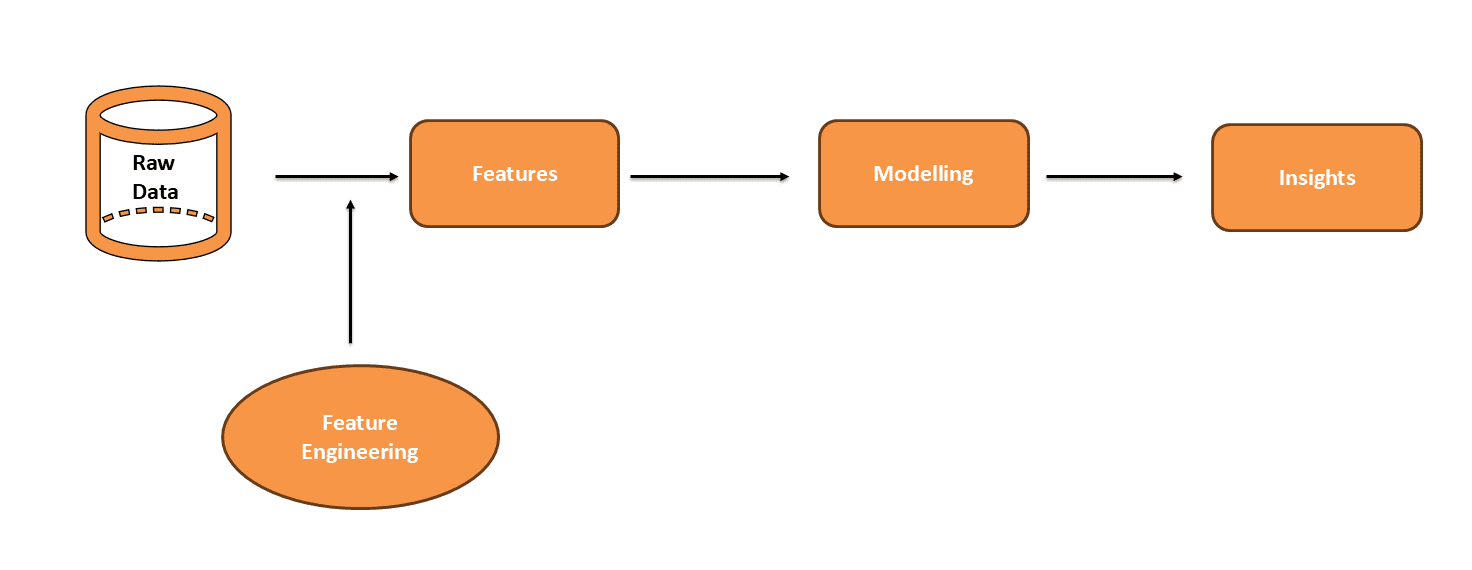

In [15]:
display(Image(filename=r"C:\Users\Jeet Roy\Downloads\Feature-Engineering 1.png", width=800))

In [16]:
#the process of transforming raw data into informative variables (features) that help machine learning models learn patterns more

In [17]:
#Return of Investment
df["roi"]=df["gross"]/df["budget"]

In [18]:
#Profit
df["profit"]=df["gross"]-df["budget"]

In [19]:
#Cast Popularity
df["cast_popularity"]=(df["actor_1_facebook_likes"]+df["actor_2_facebook_likes"]+df["actor_3_facebook_likes"])

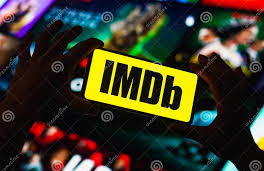

In [20]:
display(Image(filename=r"C:\Users\Jeet Roy\Downloads\IMDB.png", width=900))

**Target Variable**

In [21]:
def rate(score):
    if score < 5.5:
        return "flop"
    elif score == 5.5 and score < 6.6:
        return "average"
    elif score ==6.7 and score < 7.5:
        return "hit"
    else:
        return "superhit"

In [22]:
df["success_cat"]=df["imdb_score"].apply(rate)

### IMDb Rating & Box Office Tier Breakdown

*   **Superhit / Blockbuster (7.6 and Above)**
    *   **Audience Reception:** Widespread critical acclaim; exceptional word-of-mouth.
    *   **Box Office Outcome:** Exceptional return on investment; dominant box office run.
    *   **Examples:** Elite cinematic masterpieces found on the IMDb Top 250 list.

*   **Hit (6.7 – 7.5)**
    *   **Audience Reception:** Generally positive reviews; highly recommended.
    *   **Box Office Outcome:** Secures solid profitability and strong theater footfalls.
    *   **Examples:** Popular mainstream movies with consistent word-of-mouth success.

*   **Average (5.5 – 6.6)**
    *   **Audience Reception:** Mixed reactions; enjoyable to genre fans but structurally flawed.
    *   **Box Office Outcome:** Recovers base production costs or achieves minor profitability.
    *   **Examples:** Decent time-killers that serve a baseline mainstream audience.

*   **Flop / Disaster (Below 5.5)**
    *   **Audience Reception:** Universally panned; heavy negative reviews for script or acting.
    *   **Box Office Outcome:** Fails to recover production and marketing costs.
    *   **Examples:** Critical misfires heavily rejected by general audiences.

**Target Value Distribution**

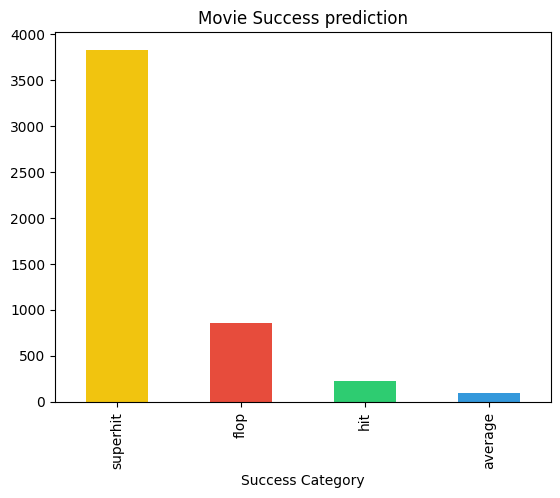

In [23]:
df["success_cat"].value_counts().plot(
    kind="bar",
    color=['#F1C40F','#E74C3C','#2ECC71', '#3498DB' ])
plt.title("Movie Success prediction")
plt.xlabel("Success Category")
plt.show()

**Correlation**

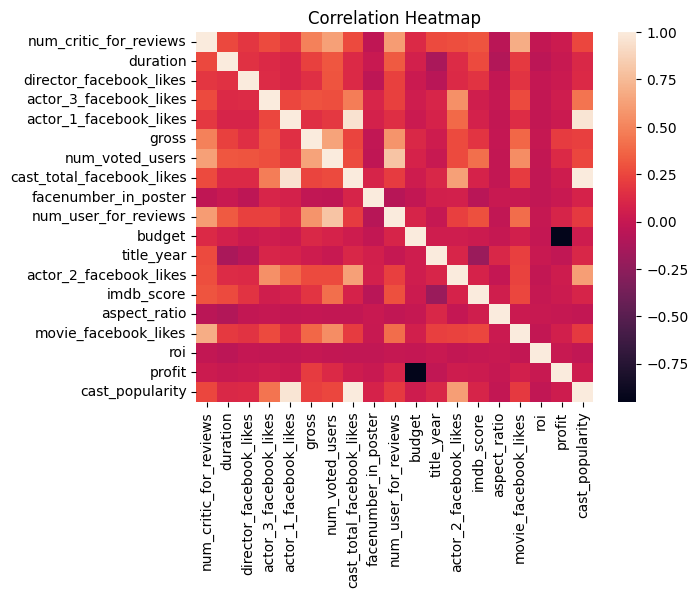

In [24]:
sns.heatmap(df.corr(numeric_only=True),annot=False)
plt.title("Correlation Heatmap")
plt.show()

**Budget vs Gross**

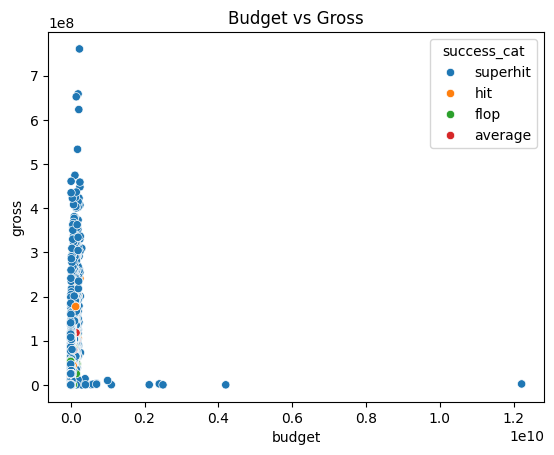

In [25]:
sns.scatterplot(x="budget",y="gross",hue="success_cat",data=df)
plt.title("Budget vs Gross")
plt.show()

**Top Genres**

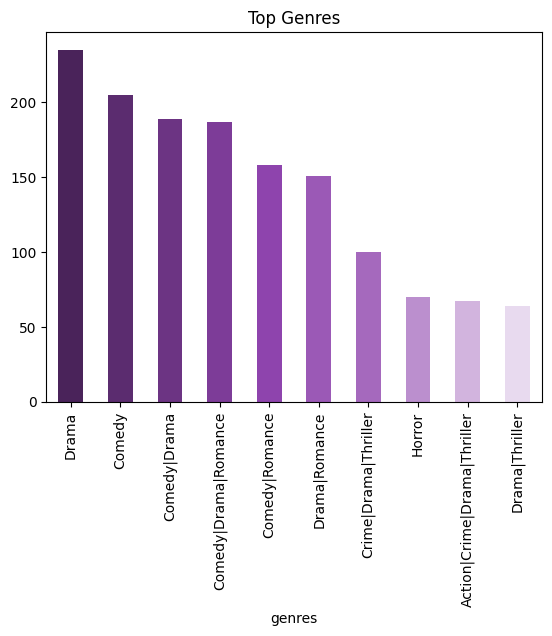

In [26]:
purple_shades = [
    '#4A235A',
    '#5B2C6F',
    '#6C3483',
    '#7D3C98',
    '#8E44AD',
    '#9B59B6',
    '#A569BD',
    '#BB8FCE',
    '#D2B4DE',
    '#E8DAEF'
]

top_genres=df["genres"].value_counts().head(10)
top_genres.plot(kind="bar",color=purple_shades)
plt.title("Top Genres")
plt.show()

**IMDb Distribution**

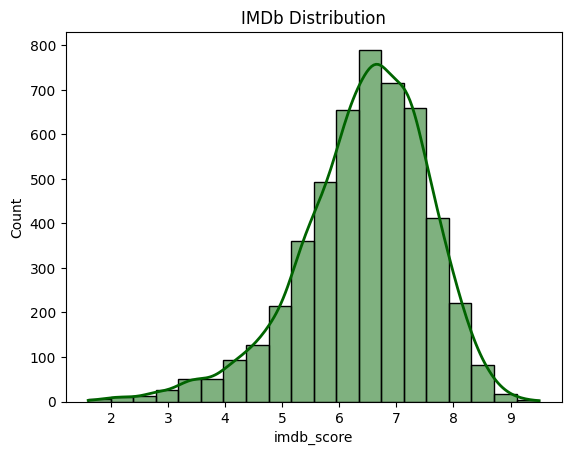

In [27]:
sns.histplot(x="imdb_score",data=df,bins=20,kde=True,color='darkgreen',line_kws={'linewidth': 2})
plt.title("IMDb Distribution")
plt.show()

**Director Analysis**

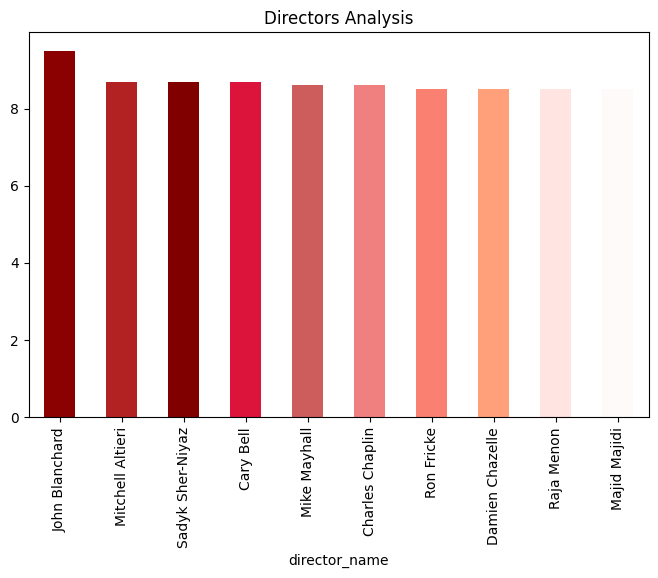

In [28]:
colors = ["#8B0000", "#B22222", "#800000", "#DC143C", "#CD5C5C",
          "#F08080", "#FA8072", "#FFA07A", "#FFE4E1", "#FFFAFA"]

directors=df.groupby("director_name")["imdb_score"].mean()
top_director=directors.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_director.plot(kind="bar",color=colors)
plt.title("Directors Analysis")
plt.show()

**Machine Learning** 

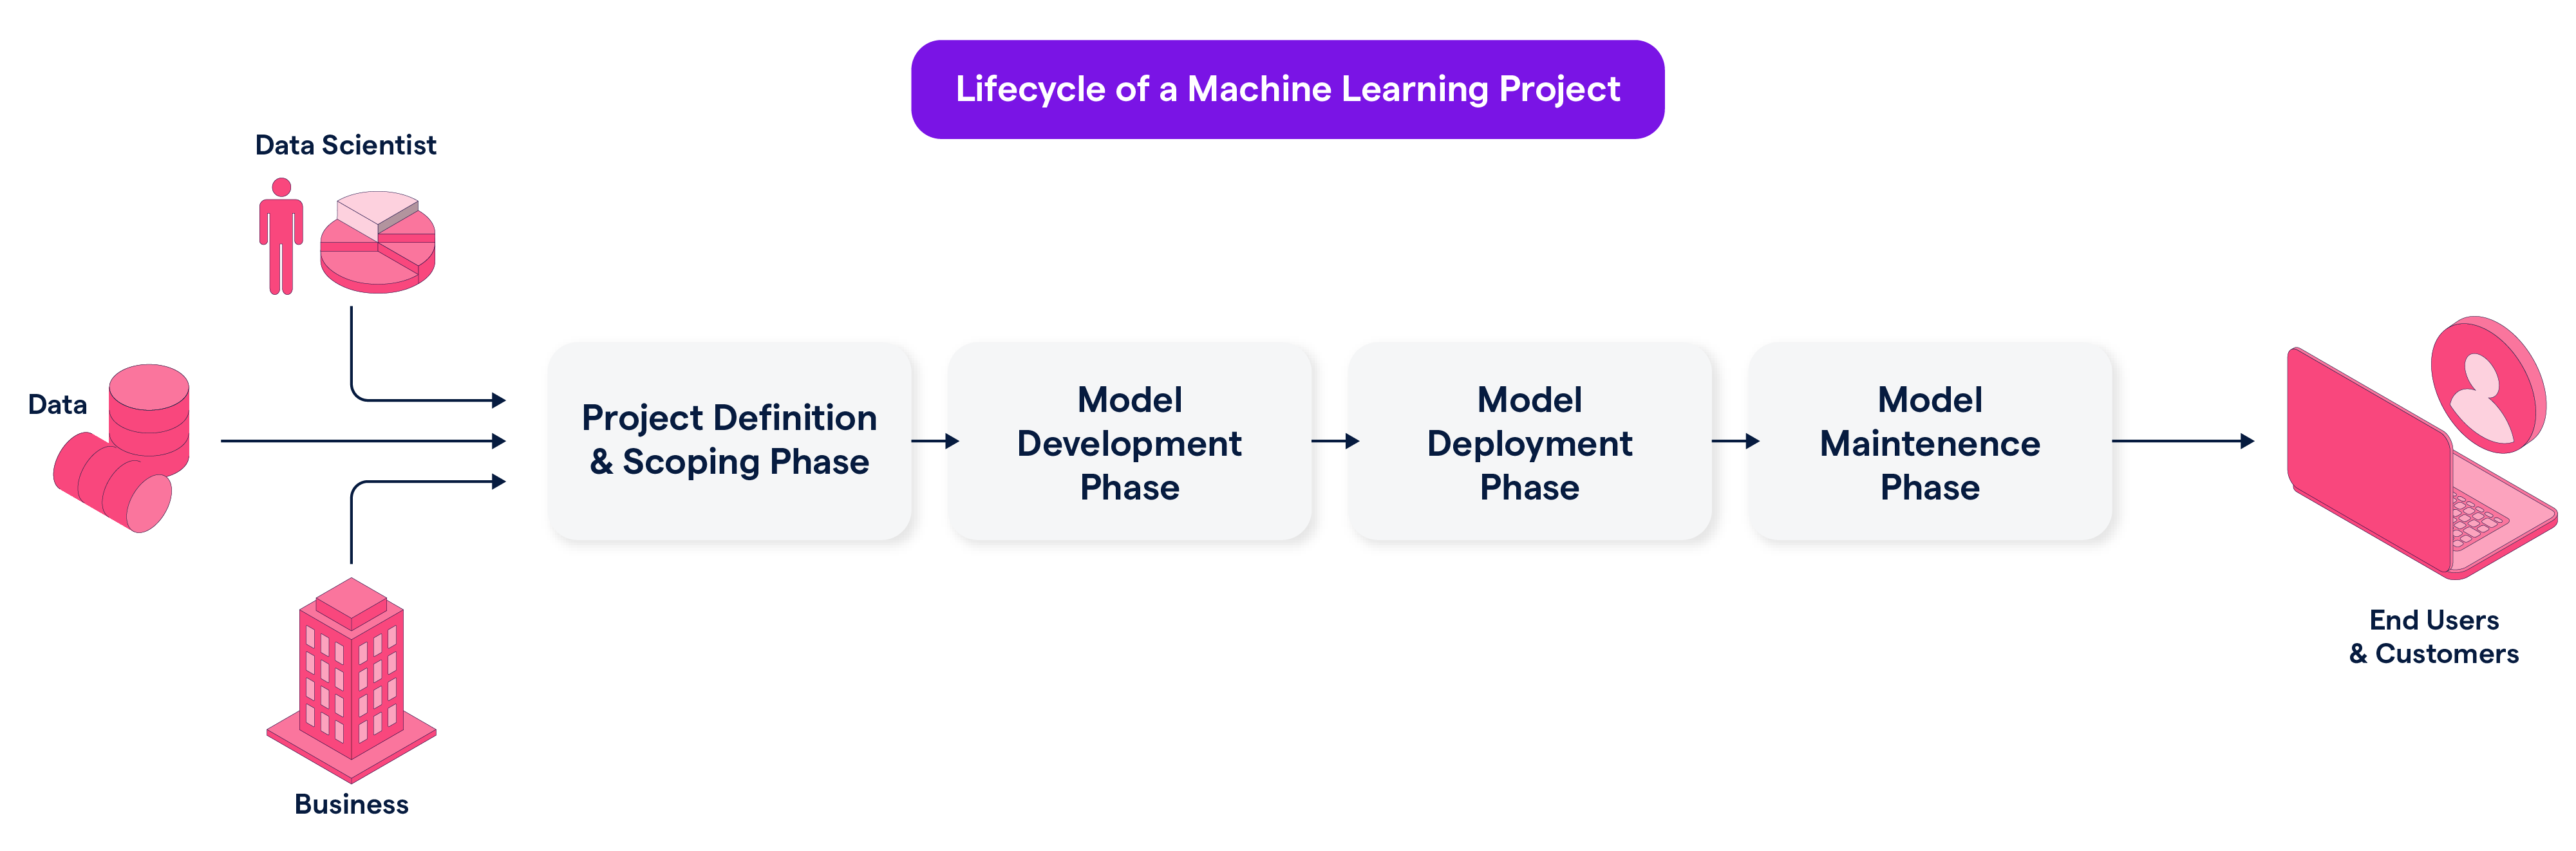

In [29]:
display(Image(filename=r"C:\Users\Jeet Roy\Downloads\ML model.png", width=700))

**Select Features**

In [30]:
features=["budget","gross","roi","profit","cast_popularity","num_voted_users","duration","director_facebook_likes","movie_facebook_likes"]

In [31]:
x=df[features]

In [32]:
y=df["success_cat"]

**Encode Variable**

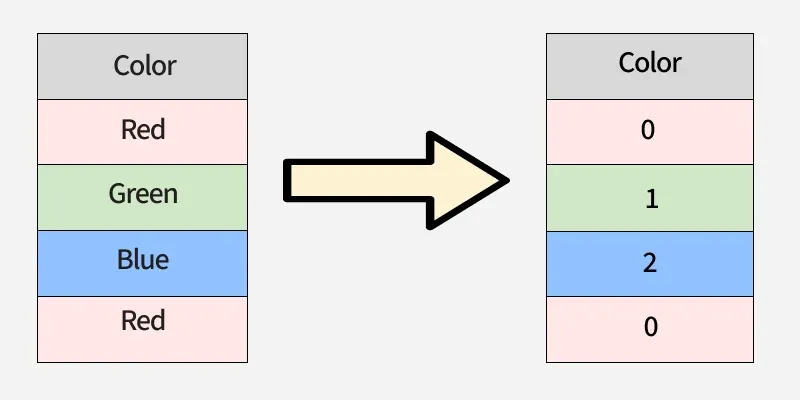

In [33]:
display(Image(filename=r"C:\Users\Jeet Roy\Downloads\label encoding.webp", width=700))

In [34]:
# Label Encoder is a utility in machine learning used to convert categorical text or string data into numerical values
label=LabelEncoder()
y=label.fit_transform(y) # # applies stored parameters to data and returns transformed data

**Train Test Split**

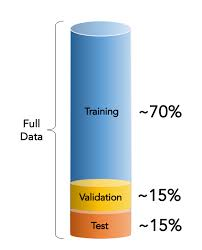

In [35]:
display(Image(filename=r"C:\Users\Jeet Roy\Downloads\train test split.jpg", width=300))

In [36]:
#Train Test Split is a machine learning technique used to evaluate the performance of a predictive model
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

**Features Scalling**

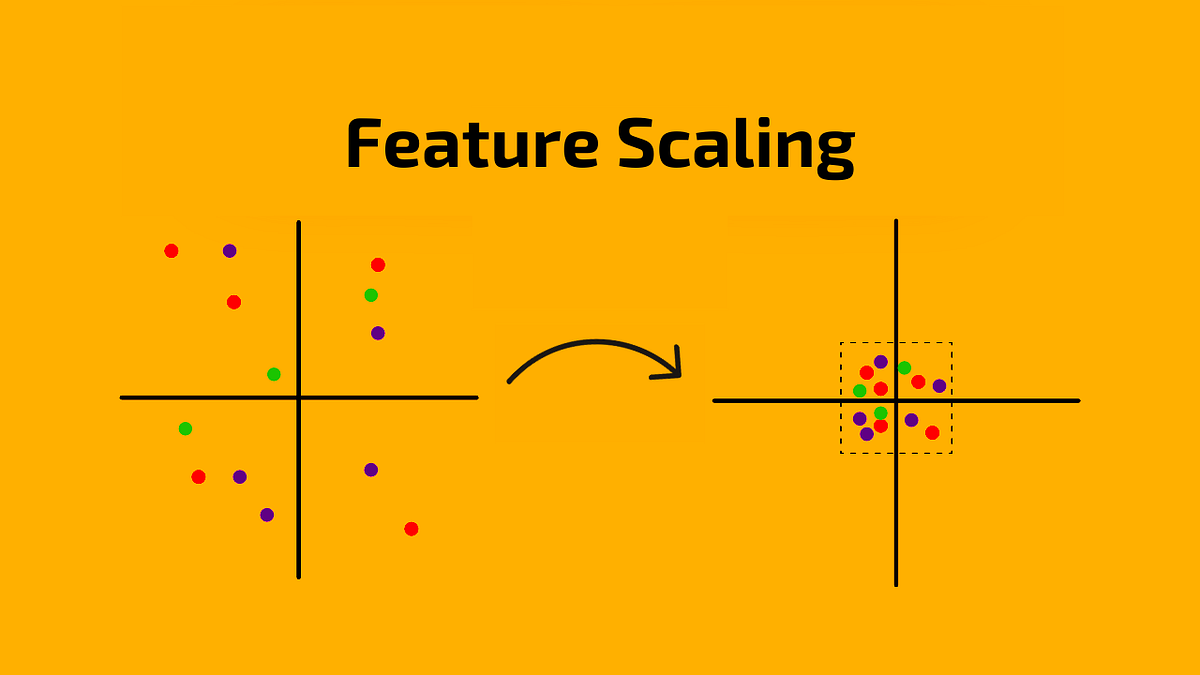

In [37]:
display(Image(filename=r"C:\Users\Jeet Roy\Downloads\feature scalling.png", width=700))

In [38]:
#Standard Scaler is a data preprocessing technique used to normalize the range of independent variables (features) in a dataset
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train) 
x_test=scaler.transform(x_test)       # applies stored parameters to data and returns transformed data

### <u>Models

**Logistic Regression**

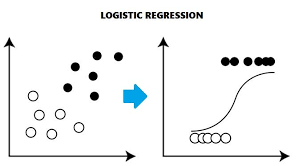

In [39]:
display(Image(filename=r"C:\Users\Jeet Roy\Downloads\logistic reg.png", width=500))

In [40]:
log=LogisticRegression()
log.fit(x_train,y_train)
y_pred_log=log.predict(x_test)

print("logistic Regression Accuracy")
print(accuracy_score(y_test,y_pred_log))

logistic Regression Accuracy
0.76


**Decision Tree**

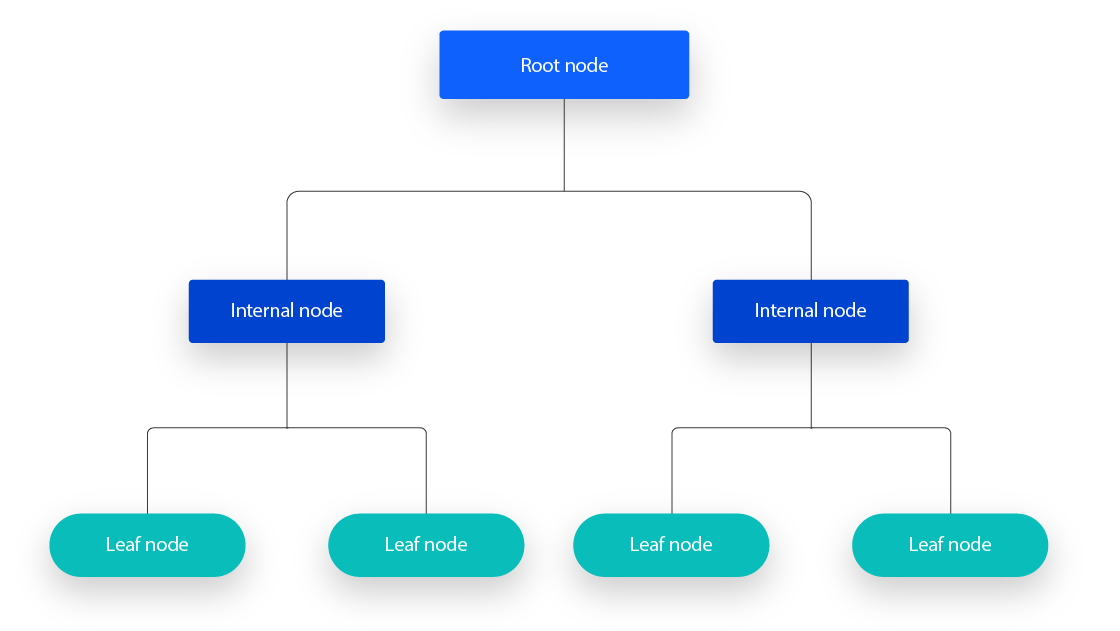

In [41]:
display(Image(filename=r"C:\Users\Jeet Roy\Downloads\dec tree.png", width=700))

In [42]:
dec=DecisionTreeClassifier()
dec.fit(x_train,y_train)
y_pred_dec=dec.predict(x_test)

print("Decision Tree Accuracy")
print(accuracy_score(y_test,y_pred_dec))

Decision Tree Accuracy
0.695


**Random Forest**

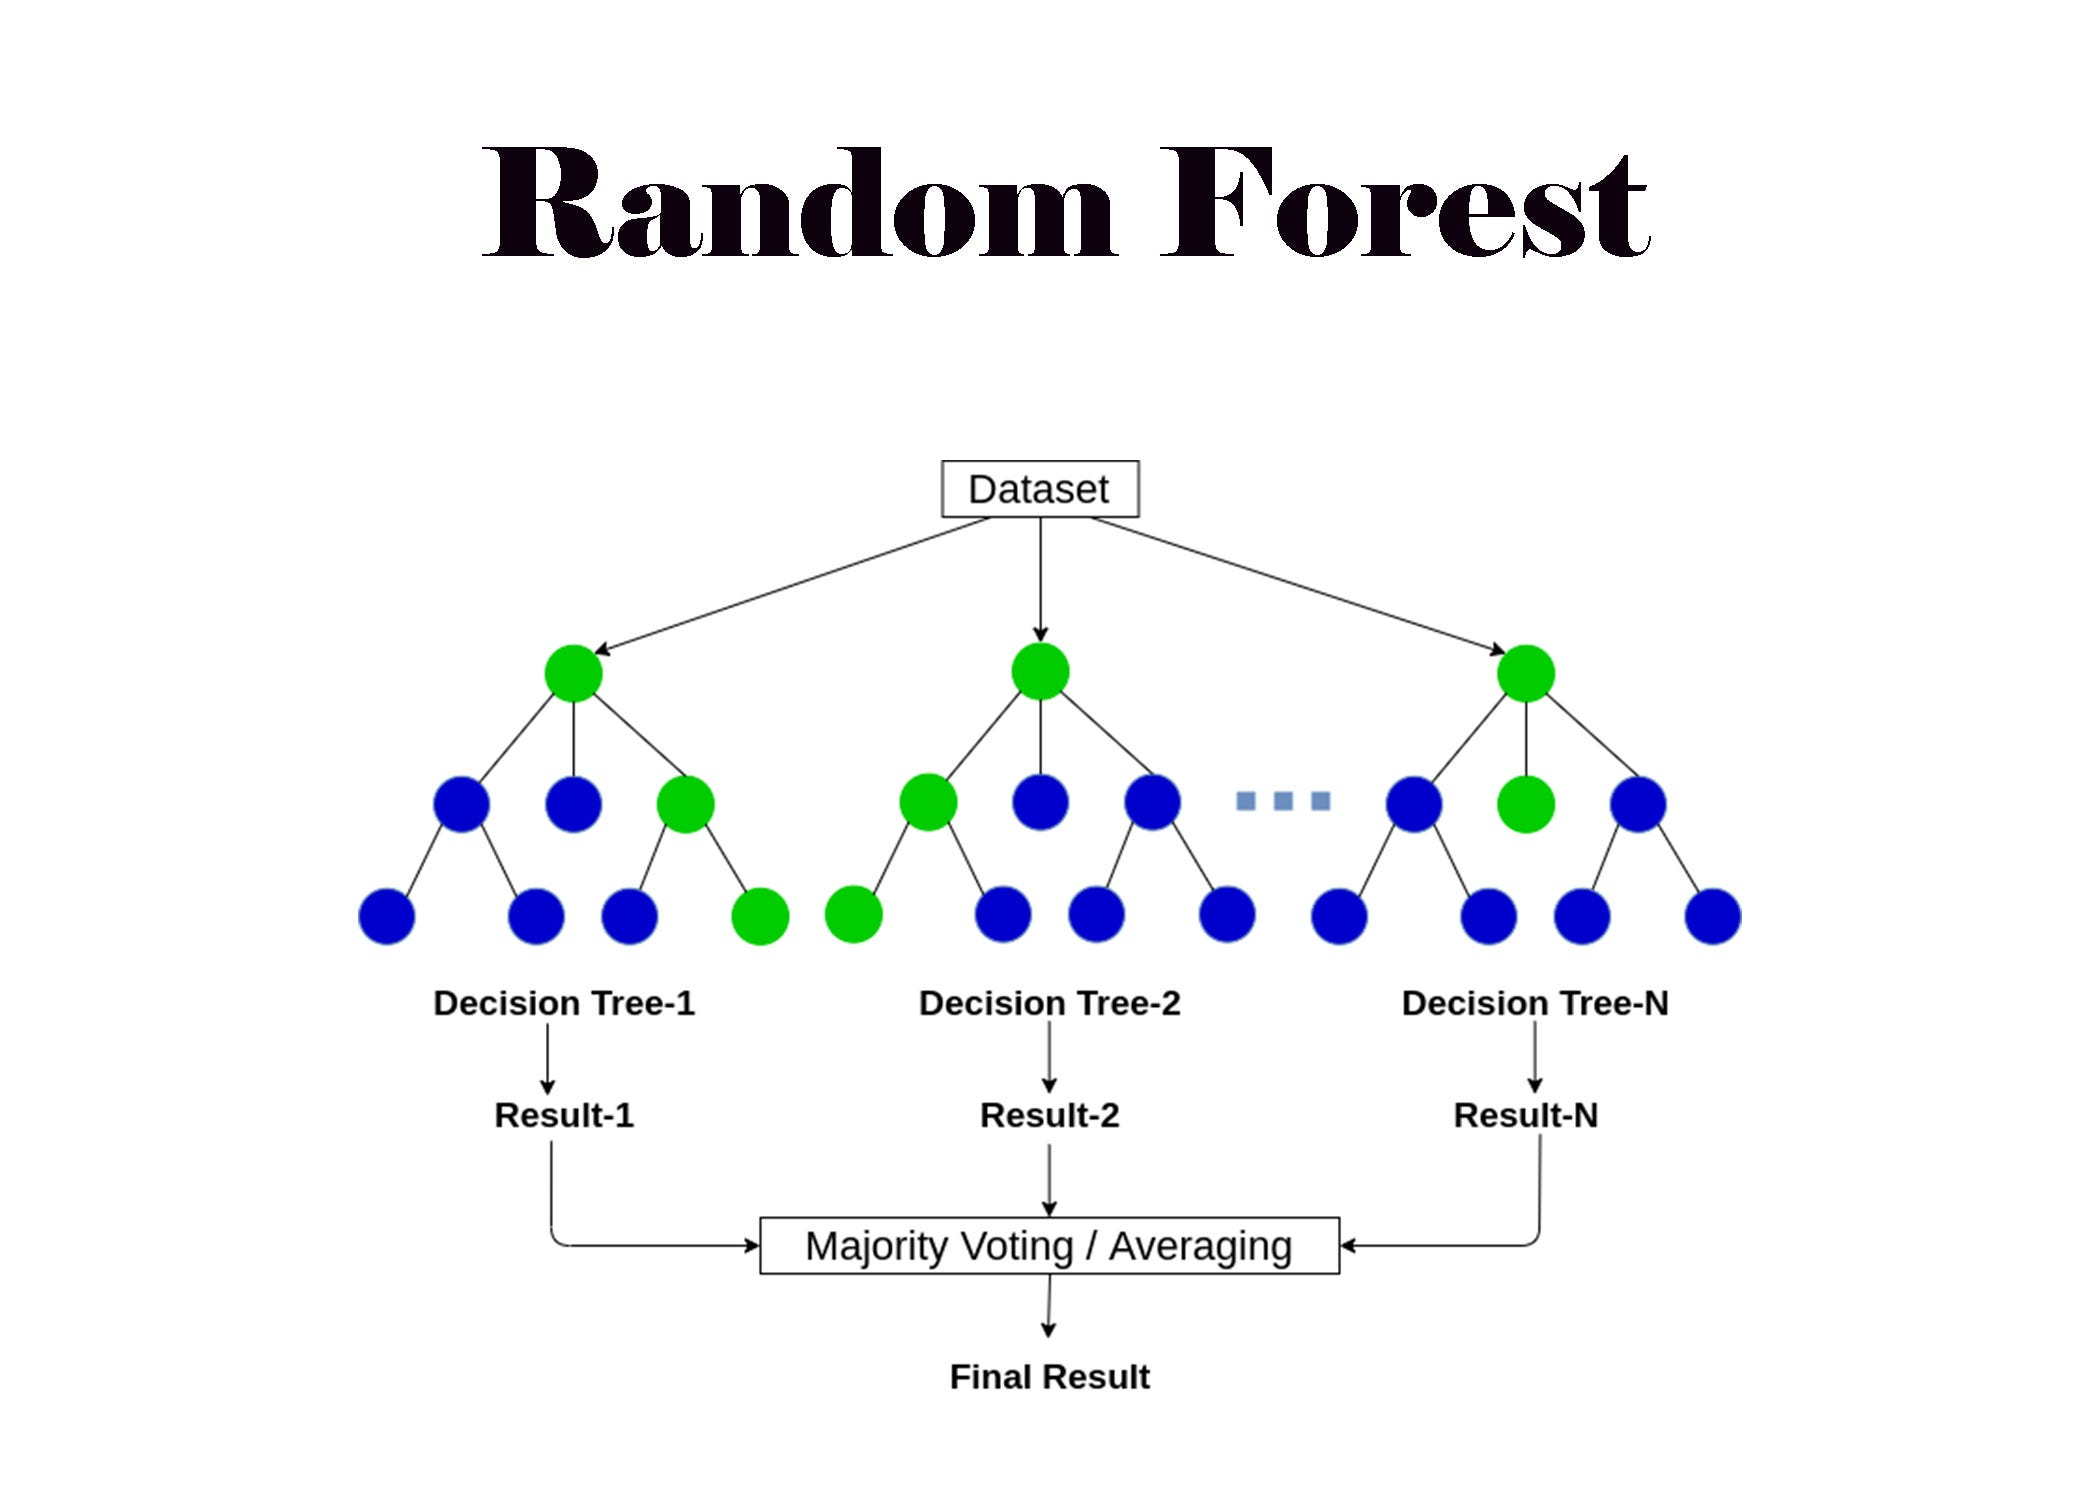

In [43]:
display(Image(filename=r"C:\Users\Jeet Roy\Downloads\ran.jpg", width=600))

In [44]:
ran=RandomForestClassifier()
ran.fit(x_train,y_train)
y_pred_ran=ran.predict(x_test)

print("Random Forest Accuracy")
print(accuracy_score(y_test,y_pred_ran))

Random Forest Accuracy
0.791


**K Nearest Neighbor**

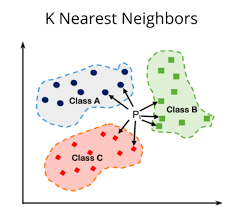

In [45]:
display(Image(filename=r"C:\Users\Jeet Roy\Downloads\k.png", width=500))

In [46]:
kn=KNeighborsClassifier()
kn.fit(x_train,y_train)
y_pred_kn=kn.predict(x_test)

print("K Nearest Neighbors")
print(accuracy_score(y_test,y_pred_kn))

K Nearest Neighbors
0.767


**Model Comparison**

In [47]:
models=pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_log),
        accuracy_score(y_test,y_pred_dec),
        accuracy_score(y_test,y_pred_ran),
        accuracy_score(y_test,y_pred_kn)
        
    ]
}
    
)

In [48]:
models

,Model,Accuracy
0,Logistic Regression,0.760
1,Decision Tree,0.695
2,Random Forest,0.791
3,KNN,0.767


**Model Comparision Chart**


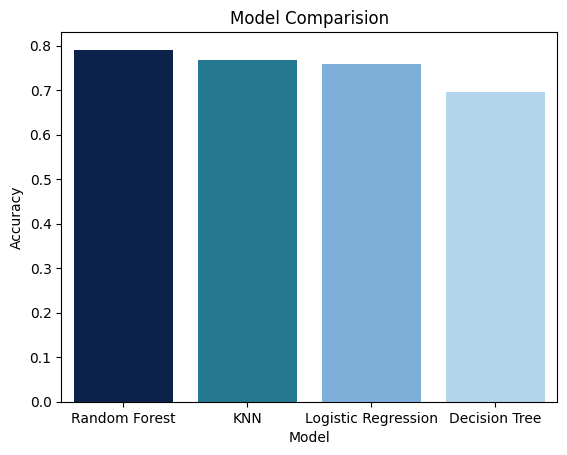

In [49]:
blue = ['#001F54', '#1282A2',  '#6FB1E7', '#A9D6F5']


sort_model=models.sort_values(by="Accuracy",ascending=False)
sns.barplot(x="Model",y="Accuracy",data =sort_model,palette=blue)
plt.title("Model Comparision")
plt.show()

**Confusion Matrix** 

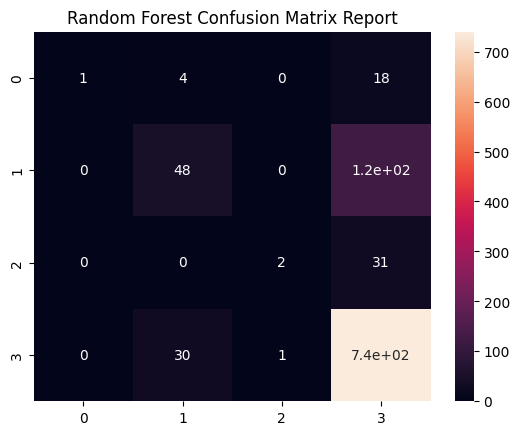

In [50]:
cm=confusion_matrix(y_test,y_pred_ran)

sns.heatmap(cm,annot=True)
plt.title("Random Forest Confusion Matrix Report")
plt.show()

**Classification Report**


In [51]:
print(classification_report(y_test,y_pred_ran))

              precision    recall  f1-score   support

           0       1.00      0.04      0.08        23
           1       0.59      0.28      0.38       173
           2       0.67      0.06      0.11        33
           3       0.81      0.96      0.88       771

    accuracy                           0.79      1000
   macro avg       0.77      0.34      0.36      1000
weighted avg       0.77      0.79      0.75      1000



### PROJECT CONCLUSION

**1. Budget and Gross strongly influence movie success.**

**2. Popular actors and directors increase success probability.**

**3. Random Forest performed best among all models.**

**4. Feature engineering improved model performance.**

**5. Machine Learning can help production companies
   make better investment decisions.**



**Converting DataFrame to CSV file**

In [65]:
df.to_csv("movie_prediction_analysis.csv",index=False)

In [66]:
models.to_csv("model_performance_comparison.csv", index=False)